In [7]:
!pip install datasets

## Load AG News Dataset

In [8]:
from datasets import load_dataset
import pandas as pd

# load news data
ds = load_dataset("ag_news")

# train split only
tr = ds["train"]

# convert to df
df = pd.DataFrame(tr)

print(df.head())
print("\nTotal rows:", len(df))


                                                text  label
0  Wall St. Bears Claw Back Into the Black (Reute...      2
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2
3  Iraq Halts Oil Exports from Main Southern Pipe...      2
4  Oil prices soar to all-time record, posing new...      2

Total rows: 120000


## Filter Only Sport & Politics

In [9]:
# keep world and sports
df = df[df["label"].isin([0,1])]

# map to binary class
mp = {0: "politics", 1: "sport"}
df["cat"] = df["label"].map(mp)

# keep required cols
df = df[["text", "cat"]]

print("Class counts:\n")
print(df["cat"].value_counts())


Class counts:

cat
sport       30000
politics    30000
Name: count, dtype: int64


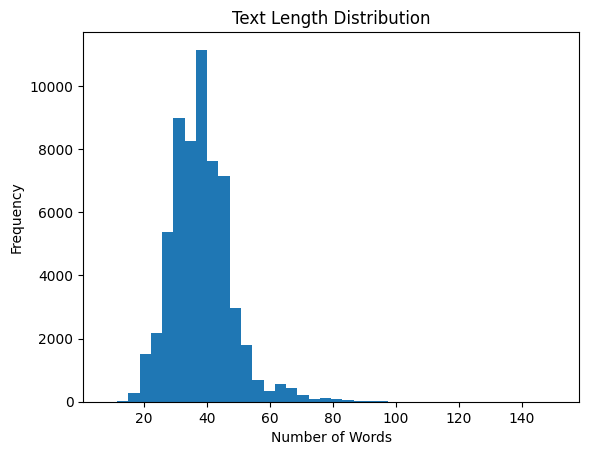

Average length: 38.3298


In [26]:
# recompute length safely
df["ln"] = df["text"].apply(lambda x: len(x.split()))

plt.figure()
plt.hist(df["ln"], bins=40)
plt.title("Text Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

print("Average length:", df["ln"].mean())

## Data Check

In [10]:
# check shape
print("Shape:", df.shape)

# sample text
print("\nSample text:\n")
print(df["text"].iloc[0])

# text length stats
df["len"] = df["text"].apply(lambda x: len(x.split()))

print("\nAvg length:", df["len"].mean())
print("Min length:", df["len"].min())
print("Max length:", df["len"].max())


Shape: (60000, 2)

Sample text:

Phelps, Thorpe Advance in 200 Freestyle (AP) AP - Michael Phelps took care of qualifying for the Olympic 200-meter freestyle semifinals Sunday, and then found out he had been added to the American team for the evening's 400 freestyle relay final. Phelps' rivals Ian Thorpe and Pieter van den Hoogenband and teammate Klete Keller were faster than the teenager in the 200 free preliminaries.

Avg length: 38.3298
Min length: 8
Max length: 151


## Train Test Split

In [11]:
from sklearn.model_selection import train_test_split

# features and labels
X = df["text"]
y = df["cat"]

# split data 80 20
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_tr))
print("Test size:", len(X_te))

Train size: 48000
Test size: 12000


## Bag of Words Features

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

# bow features
cv = CountVectorizer(
    stop_words="english",
    max_df=0.8
)

# fit train only
Xtr_b = cv.fit_transform(X_tr)
Xte_b = cv.transform(X_te)

print("BoW shape:", Xtr_b.shape)


BoW shape: (48000, 41111)


## TF-IDF Features (Unigram)

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf unigram
tv = TfidfVectorizer(
    stop_words="english",
    max_df=0.8
)

# fit train only
Xtr_t = tv.fit_transform(X_tr)
Xte_t = tv.transform(X_te)

print("TFIDF shape:", Xtr_t.shape)


TFIDF shape: (48000, 41111)


## TF-IDF with Bigrams (n-grams)

In [14]:
# tfidf bigram
tv2 = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    max_features=50000,
    max_df=0.8
)

# fit train only
Xtr_g = tv2.fit_transform(X_tr)
Xte_g = tv2.transform(X_te)

print("TFIDF bigram shape:", Xtr_g.shape)


TFIDF bigram shape: (48000, 50000)


## Visualize Feature Size Comparison

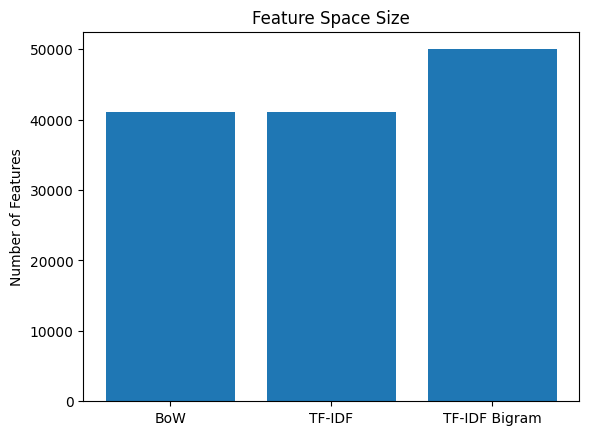

In [15]:
import matplotlib.pyplot as plt

# feature sizes
sz = [
    Xtr_b.shape[1],
    Xtr_t.shape[1],
    Xtr_g.shape[1]
]

nm = ["BoW", "TF-IDF", "TF-IDF Bigram"]

plt.figure()
plt.bar(nm, sz)
plt.title("Feature Space Size")
plt.ylabel("Number of Features")
plt.show()

## Top Words (TF-IDF)

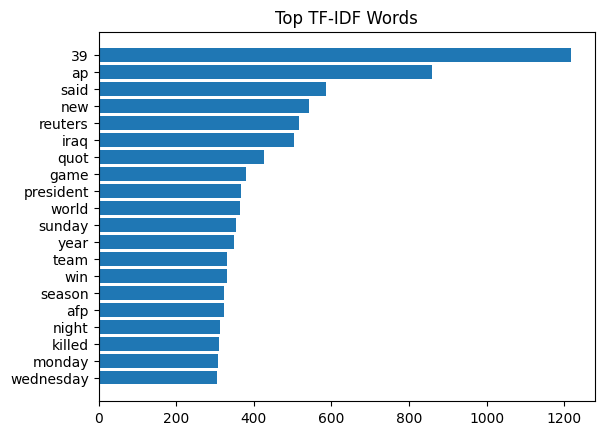

In [16]:
import numpy as np

# get feature names
fn = tv.get_feature_names_out()

# sum tfidf weights
imp = np.asarray(Xtr_t.sum(axis=0)).ravel()

# top 20 words
idx = imp.argsort()[-20:]

top_w = fn[idx]
top_s = imp[idx]

plt.figure()
plt.barh(top_w, top_s)
plt.title("Top TF-IDF Words")
plt.show()

In [17]:
## 2D Visualization using PCA

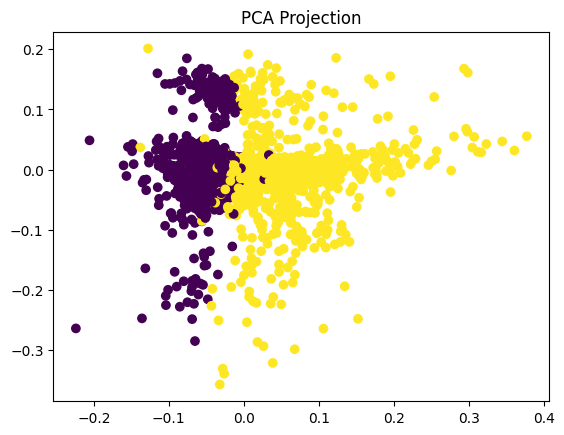

In [18]:
from sklearn.decomposition import PCA

# take small sample
Xs = Xtr_t[:2000].toarray()
ys = y_tr[:2000]

pca = PCA(n_components=2)
X2 = pca.fit_transform(Xs)

plt.figure()
plt.scatter(X2[:,0], X2[:,1], c=[0 if i=="sport" else 1 for i in ys])
plt.title("PCA Projection")
plt.show()

# Model Train

## Train Train MultinomialNB (TF-IDF)

In [19]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# nb model
mnb = MultinomialNB()

# fit model
mnb.fit(Xtr_t, y_tr)

# test predict
pr_nb = mnb.predict(Xte_t)

# show metrics
print("NB Acc:", accuracy_score(y_te, pr_nb))
print("NB Pre:", precision_score(y_te, pr_nb, average="weighted"))
print("NB Rec:", recall_score(y_te, pr_nb, average="weighted"))
print("NB F1 :", f1_score(y_te, pr_nb, average="weighted"))

NB Acc: 0.97325
NB Pre: 0.9735041270344009
NB Rec: 0.97325
NB F1 : 0.9732464103742697


## CELL Train Linear SVM (TF-IDF Bigram)

In [20]:
from sklearn.svm import LinearSVC

# svm model
lsv = LinearSVC()

# fit model
lsv.fit(Xtr_g, y_tr)

# test predict
pr_sv = lsv.predict(Xte_g)

# show metrics
print("SVM Acc:", accuracy_score(y_te, pr_sv))
print("SVM Pre:", precision_score(y_te, pr_sv, average="weighted"))
print("SVM Rec:", recall_score(y_te, pr_sv, average="weighted"))
print("SVM F1 :", f1_score(y_te, pr_sv, average="weighted"))

SVM Acc: 0.9794166666666667
SVM Pre: 0.9795084259318401
SVM Rec: 0.9794166666666667
SVM F1 : 0.9794156819071713


## Train Random Forest (TF-IDF)

In [21]:
from sklearn.ensemble import RandomForestClassifier

# rf model
rf = RandomForestClassifier(
    n_estimators=100,   # trees count
    max_depth=None,     # full depth
    random_state=42
)

# fit model
rf.fit(Xtr_t, y_tr)

# test predict
pr_rf = rf.predict(Xte_t)

# show metrics
print("RF Acc:", accuracy_score(y_te, pr_rf))
print("RF Pre:", precision_score(y_te, pr_rf, average="weighted"))
print("RF Rec:", recall_score(y_te, pr_rf, average="weighted"))
print("RF F1 :", f1_score(y_te, pr_rf, average="weighted"))

RF Acc: 0.969
RF Pre: 0.9691753673261874
RF Rec: 0.969
RF F1 : 0.9689971029515091


## Compare All Models

In [22]:
res = {
    "Model": ["NB", "SVM", "RF"],
    "Accuracy": [
        accuracy_score(y_te, pr_nb),
        accuracy_score(y_te, pr_sv),
        accuracy_score(y_te, pr_rf)
    ],
    "Precision": [
        precision_score(y_te, pr_nb, average="weighted"),
        precision_score(y_te, pr_sv, average="weighted"),
        precision_score(y_te, pr_rf, average="weighted")
    ],
    "Recall": [
        recall_score(y_te, pr_nb, average="weighted"),
        recall_score(y_te, pr_sv, average="weighted"),
        recall_score(y_te, pr_rf, average="weighted")
    ],
    "F1": [
        f1_score(y_te, pr_nb, average="weighted"),
        f1_score(y_te, pr_sv, average="weighted"),
        f1_score(y_te, pr_rf, average="weighted")
    ]
}

tbl = pd.DataFrame(res)
tbl

,Model,Accuracy,Precision,Recall,F1
0,NB,0.973250,0.973504,0.973250,0.973246
1,SVM,0.979417,0.979508,0.979417,0.979416
2,RF,0.969000,0.969175,0.969000,0.968997


In [36]:
import matplotlib.pyplot as plt
import numpy as np

# metric values
a = [
    accuracy_score(y_te, pr_nb),
    accuracy_score(y_te, pr_sv),
    accuracy_score(y_te, pr_rf)
]

p = [
    precision_score(y_te, pr_nb, average="weighted"),
    precision_score(y_te, pr_sv, average="weighted"),
    precision_score(y_te, pr_rf, average="weighted")
]

r = [
    recall_score(y_te, pr_nb, average="weighted"),
    recall_score(y_te, pr_sv, average="weighted"),
    recall_score(y_te, pr_rf, average="weighted")
]

f = [
    f1_score(y_te, pr_nb, average="weighted"),
    f1_score(y_te, pr_sv, average="weighted"),
    f1_score(y_te, pr_rf, average="weighted")
]

m = ["NB", "SVM", "RF"]
x = np.arange(len(m))

## Accuracy Plot

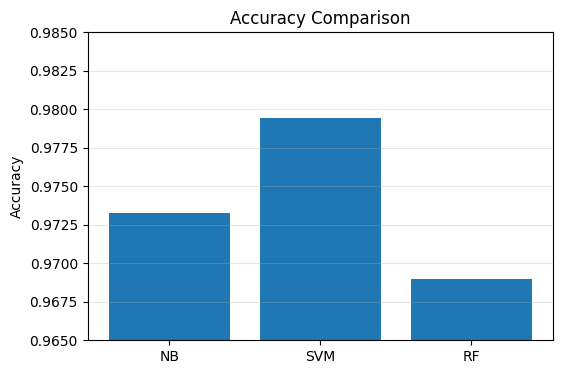

In [37]:
plt.figure(figsize=(6,4))
plt.bar(m, a)
plt.ylim(0.965, 0.985)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Precision Plot

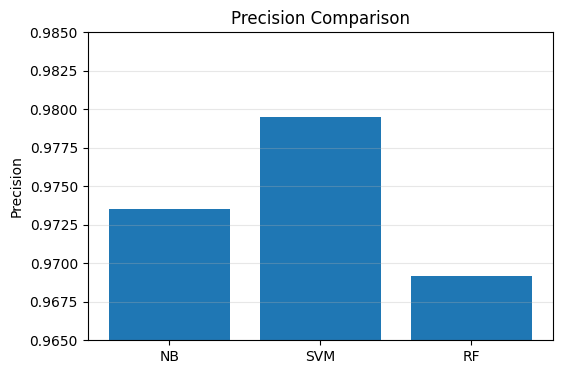

In [38]:
plt.figure(figsize=(6,4))
plt.bar(m, p)
plt.ylim(0.965, 0.985)
plt.title("Precision Comparison")
plt.ylabel("Precision")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Recall Plot

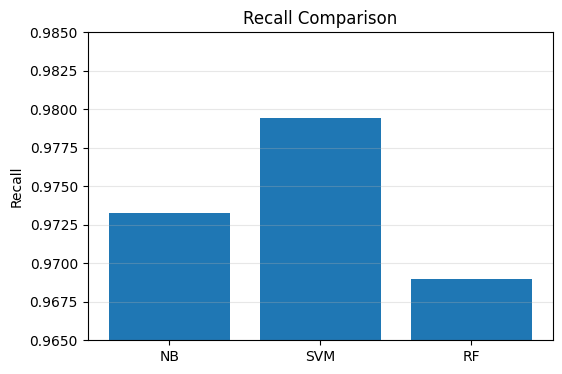

In [39]:
plt.figure(figsize=(6,4))
plt.bar(m, r)
plt.ylim(0.965, 0.985)
plt.title("Recall Comparison")
plt.ylabel("Recall")
plt.grid(axis="y", alpha=0.3)
plt.show()

## F1 Plot

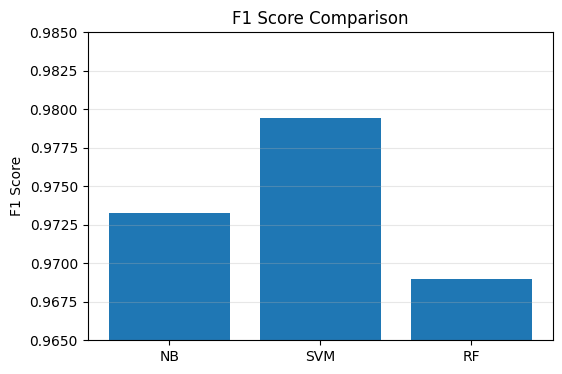

In [40]:
plt.figure(figsize=(6,4))
plt.bar(m, f)
plt.ylim(0.965, 0.985)
plt.title("F1 Score Comparison")
plt.ylabel("F1 Score")
plt.grid(axis="y", alpha=0.3)
plt.show()

#Prediction Function

In [23]:
# final predict func
def pred_txt(t, mdl, vec):
    # transform text
    v = vec.transform([t])

    # model predict
    p = mdl.predict(v)

    return p[0]

In [24]:
# sample input
txt1 = "The government passed a new economic policy today."

out1 = pred_txt(txt1, lsv, tv2)

print("Input:", txt1)
print("Output:", out1)

Input: The government passed a new economic policy today.
Output: politics


# user input


In [30]:
while True:
    u = input("Enter text (exit to stop): ")

    if u.lower() == "exit":
        break

    r = pred_txt(u, lsv, tv2)
    print("Predicted:", r)
    print()

Enter text (exit to stop): The government not passed a new economic policy today.
Predicted: politics



KeyboardInterrupt: Interrupted by user